In [2]:
import os
os.environ["MPLBACKEND"] = "Agg"

In [3]:
!pip install --upgrade ultralytics numpy "numpy<2" opencv-python-headless torch torchvision torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 35.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.8/899.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 12.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 18.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 39.0 MB/s eta 0

In [4]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
model=YOLO('yolov8n.pt')
results = model.train(    data="/kaggle/input/raindata-labels/data/data.yaml",
                      epochs=100,
                      imgsz=640,
                      device='cuda',
                     batch=16,                 
                    conf=0.25,               
                    iou=0.5
                )

Ultralytics 8.3.227 🚀 Python-3.11.13 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/raindata-labels/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         60        168       0.39      0.899      0.433      0.252
                human1         24         24        0.4          1       0.45       0.28
                human2         24         24        0.4          1      0.473      0.294
                human3         24         24        0.4          1       0.48      0.345
                human4         24         24      0.341      0.583      0.357      0.174
                human5         24         24      0.391       0.75      0.384      0.192
                human6         24         25        0.4       0.96      0.471      0.236
                human7         23         23      0.397          1      0.415      0.243
Speed: 0.2ms preprocess, 1.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/train


In [6]:
results_val = model.val(
    data="/kaggle/input/raindata-labels/data/data.yaml",
    imgsz=640,
    device=0,
    conf=0.25,
    iou=0.5,
)

Ultralytics 8.3.227 🚀 Python-3.11.13 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1517.2±116.1 MB/s, size: 2312.2 KB)
val: Scanning /kaggle/input/raindata-labels/data/source_images/images_val... 24 images, 36 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 176.2it/s 0.3s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/raindata-labels/data/source_images is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 2.8s0.8ss


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         60        168      0.393      0.911      0.443      0.259
                human1         24         24        0.4          1       0.46      0.284
                human2         24         24        0.4          1      0.487      0.306
                human3         24         24        0.4          1       0.48      0.345
                human4         24         24      0.372      0.667      0.378      0.191
                human5         24         24      0.383       0.75      0.383       0.19
                human6         24         25        0.4       0.96      0.471      0.238
                human7         23         23      0.397          1      0.439      0.256
Speed: 6.5ms preprocess, 9.0ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


In [26]:
import os, glob
base = "/kaggle/working/runs/detect"
print("Subdirs:", os.listdir(base))
for d in os.listdir(base):
    w = glob.glob(f"{base}/{d}/weights/*.pt")
    if w:
        print(d, "->", w)


Subdirs: ['val', 'predict', 'train']
train -> ['/kaggle/working/runs/detect/train/weights/last.pt', '/kaggle/working/runs/detect/train/weights/best.pt']


In [7]:
def print_metrics(tag, r):
    d = r.results_dict
    map5095 = d.get("metrics/mAP50-95(B)")
    map50   = d.get("metrics/mAP50(B)")
    prec    = d.get("metrics/precision(B)")
    rec     = d.get("metrics/recall(B)")
    box_l   = d.get("train/box_loss") or d.get("val/box_loss")

    print(f"\n[{tag}] mAP50-95 (средняя точность по IoU 0.50–0.95): {map5095}")
    print(f"[{tag}] mAP50 (средняя точность по IoU 0.50): {map50}")
    print(f"[{tag}] Precision (доля верных среди предсказаний): {prec}")
    print(f"[{tag}] Recall (доля найденных из истинных): {rec}")
    print(f"[{tag}] Box Loss (ошибка локализации боксов): {box_l}")

print_metrics("TRAIN", results)
print_metrics("VAL", results)



[TRAIN] mAP50-95 (средняя точность по IoU 0.50–0.95): 0.25191649593600585
[TRAIN] mAP50 (средняя точность по IoU 0.50): 0.4328650455588009
[TRAIN] Precision (доля верных среди предсказаний): 0.3899027837997378
[TRAIN] Recall (доля найденных из истинных): 0.8990476190476191
[TRAIN] Box Loss (ошибка локализации боксов): None

[VAL] mAP50-95 (средняя точность по IoU 0.50–0.95): 0.25191649593600585
[VAL] mAP50 (средняя точность по IoU 0.50): 0.4328650455588009
[VAL] Precision (доля верных среди предсказаний): 0.3899027837997378
[VAL] Recall (доля найденных из истинных): 0.8990476190476191
[VAL] Box Loss (ошибка локализации боксов): None


In [35]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

In [ ]:
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")
source = "/kaggle/input/raindata-labels/data/457746_Rain_Rainy_1920x1080.mp4"

conf, iou, imgsz = 0.2, 0.55, 640

for r in model.predict(source=source, imgsz=imgsz, conf=conf, iou=iou, device=0, stream=True, verbose=False):
    frame_bgr = r.plot()
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    display(plt.gcf())
    plt.close()


In [47]:
import ultralytics, sys
print("ultralytics:", ultralytics.__version__, "python:", sys.version)


ultralytics: 8.3.227 python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [55]:
model=YOLO('yolo11l.pt')

In [56]:


results = model.train(    data="/kaggle/input/raindata-labels/data/data.yaml",
                      epochs=25,
                      imgsz=640,
                      device='cuda',
                     batch=16,                 
                    conf=0.25,               
                    iou=0.5
                )

Ultralytics 8.3.227 🚀 Python-3.11.13 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/raindata-labels/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         60        168      0.388      0.694      0.431      0.223
                human1         24         24        0.4          1      0.496      0.284
                human2         24         24      0.255          1       0.44      0.249
                human3         24         24        0.5      0.375      0.386      0.219
                human4         24         24      0.367      0.917      0.531      0.183
                human5         24         24      0.333      0.125       0.22      0.145
                human6         24         25        0.4       0.96      0.518      0.233
                human7         23         23      0.458      0.478      0.427      0.249
Speed: 0.1ms preprocess, 9.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/train3


In [ ]:
base = "/kaggle/working/runs/detect"
print("Subdirs:", os.listdir(base))

# 1) Найти веса внутри train3
weights = glob.glob(f"{base}/train3/weights/*.pt")
print("train3 weights:", weights)
best = f"{base}/train3/weights/best.pt"
last = f"{base}/train3/weights/last.pt"
ckpt = best if os.path.exists(best) else (last if os.path.exists(last) else None)
results_train3 = None
if ckpt:
    model = YOLO(ckpt)

    results_train3 = model.val(data="/kaggle/input/raindata-labels/data/data.yaml", imgsz=640, device=0, verbose=False)


Subdirs: ['val', 'predict2', 'train2', 'predict', 'train', 'train3']
train3 weights: ['/kaggle/working/runs/detect/train3/weights/last.pt', '/kaggle/working/runs/detect/train3/weights/best.pt']
Ultralytics 8.3.227 🚀 Python-3.11.13 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
YOLO11l summary (fused): 190 layers, 25,284,709 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1466.6±140.9 MB/s, size: 2310.5 KB)
val: Scanning /kaggle/input/raindata-labels/data/source_images/images_val... 24 images, 36 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 176.0it/s 0.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/raindata-labels/data/source_images is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.5s1.2ss


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         60        168      0.348      0.921       0.49      0.238
Speed: 7.6ms preprocess, 22.1ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2


In [ ]:
print_metrics("RESULTS_OBJ", results)

if results_train3 is not None:
    print_metrics("TRAIN3_VAL", results_train3)
else:
    print("Не удалось найти веса в train3 или выполнить val — проверьте пути.")


[RESULTS_OBJ] mAP50-95 (средняя точность по IoU 0.50–0.95): 0.2232108897964805
[RESULTS_OBJ] mAP50 (средняя точность по IoU 0.50): 0.43108992438852883
[RESULTS_OBJ] Precision (доля верных среди предсказаний): 0.3876646403242148
[RESULTS_OBJ] Recall (доля найденных из истинных): 0.6935610766045549
[RESULTS_OBJ] Box Loss (ошибка локализации боксов): None

[TRAIN3_VAL] mAP50-95 (средняя точность по IoU 0.50–0.95): 0.23824105696393158
[TRAIN3_VAL] mAP50 (средняя точность по IoU 0.50): 0.4900323530292646
[TRAIN3_VAL] Precision (доля верных среди предсказаний): 0.3482432845648705
[TRAIN3_VAL] Recall (доля найденных из истинных): 0.921304347826087
[TRAIN3_VAL] Box Loss (ошибка локализации боксов): None


KeyboardInterrupt: 

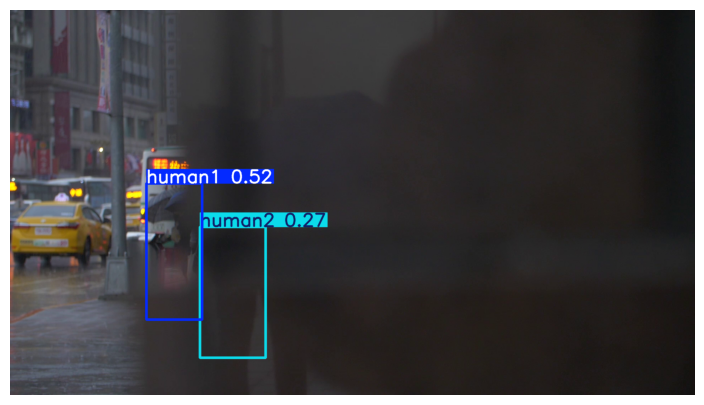

In [60]:
weights = "/kaggle/working/runs/detect/train3/weights/best.pt"   # если best нет, замени на last.pt
source  = "/kaggle/input/raindata-labels/data/457746_Rain_Rainy_1920x1080.mp4"

model = YOLO(weights)

conf, iou, imgsz = 0.2, 0.55, 640

for r in model.predict(source=source, imgsz=imgsz, conf=conf, iou=iou, device=0, stream=True, verbose=False):
    frame_bgr = r.plot()
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    display(plt.gcf())
    plt.close()
